In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/motion_CNN
    filepath = "/content/drive/MyDrive/NUIN/mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat" 
    !git pull
else: 
  filepath =  "mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat"
    

Mounted at /content/drive
/content/drive/MyDrive/NUIN/motion_CNN
Already up to date.


In [8]:
from utilities import CorrelationVelDataset, show_batch_frames, show_one_sample_summary, sample_animation
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch
import os 
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())

Using device: cuda
/content/drive/MyDrive/NUIN/motion_CNN


In [4]:
dataset = CorrelationVelDataset(
    file = filepath,
    crop_hw=(400,400),
    downsample_hw=(50,50),
    frames_per_segment=75,
    fps = 75,
    samples_per_image= 6, 
    vel_std = (350,350),
    vel_corr=-0.0
    )

print("dataset length:", len(dataset))

dataset length: 1950


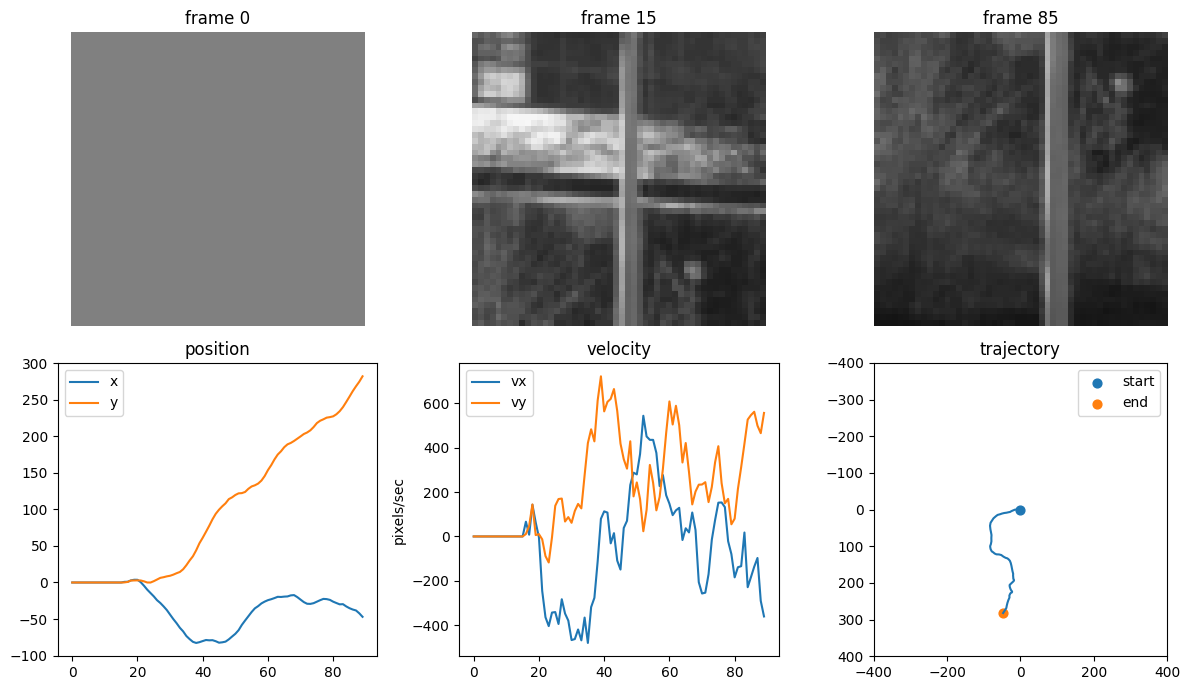

In [5]:
show_one_sample_summary(dataset, 0, frame_indices=[0,15,85])

In [19]:

anim = sample_animation(dataset, 0, viz_fps=20, save_path=None)
display(HTML(anim.to_jshtml()))

# Split/Val sets

In [6]:
from torch.utils.data import Subset, DataLoader

def split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
):
    assert abs(train_frac + val_frac - 1.0) < 1e-8

    # Unique image identities: ("frozen", image_idx), ("running", image_idx)
    image_keys = sorted({
        (meta["source"], meta["image_idx"])
        for meta in dataset.index
    })

    rng = np.random.default_rng(seed)
    image_keys = np.array(image_keys, dtype=object)
    rng.shuffle(image_keys)

    n_total = len(image_keys)
    n_train = int(round(train_frac * n_total))

    train_keys = set(map(tuple, image_keys[:n_train]))
    val_keys = set(map(tuple, image_keys[n_train:]))

    train_indices = []
    val_indices = []

    for i, meta in enumerate(dataset.index):
        key = (meta["source"], meta["image_idx"])

        if key in train_keys:
            train_indices.append(i)
        elif key in val_keys:
            val_indices.append(i)
        else:
            raise RuntimeError("Sample did not match train or val split.")

    train_dataset = Subset(dataset, train_indices)
    val_dataset = Subset(dataset, val_indices)

    return train_dataset, val_dataset, train_keys, val_keys

In [9]:

train_dataset, val_dataset, train_keys, val_keys = split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
)
print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

print("Train images:", len(train_keys))
print("Val images:", len(val_keys))

print("Overlap:", len(train_keys & val_keys))

Total samples: 1950
Train samples: 1560
Val samples: 390
Train images: 260
Val images: 65
Overlap: 0


In [ ]:
from pathlib import Path
from tqdm.auto import tqdm
import torch

def prerender_dataset_to_single_pt(
    dataset,
    indices,
    out_path,
    movie_dtype=torch.float16,
    overwrite=False,
):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.exists() and not overwrite:
        print(f"Cache already exists, skipping render: {out_path}")
        return torch.load(out_path, map_location="cpu")

    movies = []
    scene_vels = []
    scene_poss = []
    meta = []

    for idx in tqdm(indices, desc=f"Pre-rendering {out_path.name}"):
        sample = dataset[idx]

        movies.append(sample["movie"].to(dtype=movie_dtype).cpu())
        scene_vels.append(sample["scene_vel"].to(dtype=torch.float32).cpu())
        scene_poss.append(sample["scene_pos"].to(dtype=torch.float32).cpu())

        meta.append({
            "orig_idx": int(idx),
            "source": sample["source"],
            "image_idx": int(sample["image_idx"]),
        })

    cache = {
        "movie": torch.stack(movies, dim=0),
        "scene_vel": torch.stack(scene_vels, dim=0),
        "scene_pos": torch.stack(scene_poss, dim=0),
        "meta": meta,
    }

    torch.save(cache, out_path)
    print(f"Saved cache to: {out_path}")

    return cache

In [11]:
cache_name_train = (
    f"corrvel_train_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

cache_name_val = (
    f"corrvel_val_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

train_cache = prerender_dataset_to_single_pt(
    dataset,
    train_dataset.indices,
    f"cache/{cache_name_train}",
    movie_dtype=torch.float16,
    overwrite=False,
)

val_cache = prerender_dataset_to_single_pt(
    dataset,
    val_dataset.indices,
    f"cache/{cache_name_val}",
    movie_dtype=torch.float16,
    overwrite=False,
)

Pre-rendering corrvel_train.pt:   0%|          | 0/1560 [00:00<?, ?it/s]

Pre-rendering corrvel_val.pt:   0%|          | 0/390 [00:00<?, ?it/s]

In [12]:
from torch.utils.data import Dataset

class TensorMovieDataset(Dataset):
    def __init__(self, path, movie_dtype=torch.float32):
        cache = torch.load(path, map_location="cpu")

        self.movies = cache["movie"]
        self.scene_vel = cache["scene_vel"]
        self.scene_pos = cache["scene_pos"]
        self.meta = cache["meta"]
        self.movie_dtype = movie_dtype

    def __len__(self):
        return self.movies.shape[0]

    def __getitem__(self, idx):
        return {
            "movie": self.movies[idx].to(dtype=self.movie_dtype),
            "scene_vel": self.scene_vel[idx],
            "scene_pos": self.scene_pos[idx],
            "source": self.meta[idx]["source"],
            "image_idx": self.meta[idx]["image_idx"],
            "orig_idx": self.meta[idx]["orig_idx"],
        }
        
cached_train = TensorMovieDataset("cache/corrvel_train.pt", movie_dtype=torch.float32)
cached_val = TensorMovieDataset("cache/corrvel_val.pt", movie_dtype=torch.float32)

train_loader = DataLoader(
    cached_train,
    batch_size=16,
    shuffle=True,
    num_workers=0,   # try 0 first; increase later
    pin_memory=True,
)

val_loader = DataLoader(
    cached_val,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

## Tiny CNN

In [13]:
class TinyMotionCNN(nn.Module):
    def __init__(self, hidden=16, out_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv3d(1, hidden, kernel_size=(5, 5, 5), padding=(2, 2, 2)),
            nn.ReLU(inplace=True),

            nn.Conv3d(hidden, hidden, kernel_size=(5, 3, 3), padding=(2, 1, 1)),
            nn.ReLU(inplace=True),

            nn.Conv3d(hidden, 2 * hidden, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.Conv1d(2 * hidden, 2 * hidden, kernel_size=9, padding=4),
            nn.ReLU(inplace=True),
            nn.Conv1d(2 * hidden, out_dim, kernel_size=1),
        )

    def forward(self, movie):
        # movie: (B, T, 1, H, W)
        x = movie.permute(0, 2, 1, 3, 4)   # (B, 1, T, H, W)

        z = self.encoder(x)                # (B, F, T, H, W)
        z = z.mean(dim=(-1, -2))           # (B, F, T)

        y = self.decoder(z)                # (B, 2, T)
        y = y.permute(0, 2, 1)             # (B, T, 2)

        return y

In [14]:
def direct_velocity_loss(
    pred_vel_z,
    target_vel,
    vel_mean,
    vel_std,
    gray_frames,
):
    """
    pred_vel_z : (B, T, 2)
        Predicted normalized velocity.

    target_vel : (B, T, 2)
        Target velocity in raw units, e.g. px/s.
    """
    target_vel_z = (target_vel - vel_mean) / vel_std

    loss = (
        (pred_vel_z[:, gray_frames:] - target_vel_z[:, gray_frames:]) ** 2
    ).mean()

    return loss

In [15]:
def compute_velocity_stats_from_synthetic_dataset(dataset, indices=None, device="cpu"):
    """
    Fast velocity mean/std for CorrelationVelDataset.
    Does not reconstruct movies.
    
    If using a torch.utils.data.Subset for training, pass train_dataset.indices.
    """
    if indices is None:
        indices = range(len(dataset.index))

    sum_v = torch.zeros(2, device=device)
    sum_v2 = torch.zeros(2, device=device)
    n = 0

    for i in indices:
        meta = dataset.index[i]
        seed = meta["seed"]

        vel, pos = dataset.generate_velocity_trace_2d(seed=seed)

        # scene velocity is negative fixation/camera velocity
        scene_vel = -torch.from_numpy(vel).to(device)

        # no gray frames here, because generated vel is only real frames
        v = scene_vel.reshape(-1, 2)

        sum_v += v.sum(dim=0)
        sum_v2 += (v ** 2).sum(dim=0)
        n += v.shape[0]

    mean = sum_v / n
    var = sum_v2 / n - mean ** 2
    std = torch.sqrt(var + 1e-8)

    return mean, std

gray_frames = dataset.gray_frames  # probably 15

vel_mean, vel_std = compute_velocity_stats_from_synthetic_dataset(
    dataset,
    indices=train_dataset.indices,
    device=device,
)

print("vel_mean:", vel_mean)
print("vel_std:", vel_std)

vel_mean: tensor([-0.9307, -0.5621], device='cuda:0')
vel_std: tensor([322.0383, 322.3994], device='cuda:0')


In [18]:
batch = next(iter(train_loader))

movie = batch["movie"].to(device)
target = batch["scene_vel"].to(device)

tiny = TinyMotionCNN(hidden=16).to(device)
optimizer = torch.optim.AdamW(tiny.parameters(), lr=1e-3, weight_decay=0.0)

for step in range(300):
    pred = tiny(movie)

    loss = direct_velocity_loss(
        pred_vel_z=pred,
        target_vel=target,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(tiny.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 25 == 0:
        print(step, loss.item())

0 1.0639848709106445
25 0.96616131067276
50 0.9150099754333496
75 0.8019406199455261
100 0.71427321434021
125 0.6691959500312805
150 0.8644116520881653
175 0.7210516333580017
200 0.6048256754875183
225 0.5661262273788452
250 0.4446621239185333
275 0.5565903782844543


## Build NN

In [25]:
NUM_NEURONS = 8
HEIGHT = 50
WIDTH = 50
MAX_DELAY = 50


In [26]:
class CNN(nn.Module):
    """
    A convolutional neural network (CNN) model for RGC. The model consists 
    of a series of convolutional layers followed by a fully connected layer 
    to produce the mean of a Poisson spike count distribution. The model also 
    includes a nonlinear activation function between layers to capture nonlinear 
    features of the stimulus.

    Parameters
    ----------
    num_neurons : int
        The number of OUTPUT neurons in the model.
    height : int
        The height of the stimulus in pixels.
    width : int
        The width of the stimulus in pixels.
    max_delay : int
        The maximum delay in frames for the temporal convolution.
    rf_size_1 : int
        The size of the receptive field for the first layer.
    rf_size_2 : int
        The size of the receptive field for the second layer.
    num_subunits_1 : int
        The number of subunits in the first layer.
    num_subunits_2 : int
        The number of subunits in the second layer.
    mean_function : callable
        The function to compute the mean of the Poisson distribution.
    initial_bias : float
        The initial bias for the temporal convolution.
    spatial_conv : nn.Conv2d
        The convolutional layer for the spatial convolution.
    temporal_conv : nn.Conv1d
        The convolutional layer for the temporal convolution.
    layer2 : nn.Conv2d
        The convolutional layer for the second layer.
    layer3 : nn.Linear
        The fully connected layer for the output.
    """
    num_neurons: int
    height: int
    width: int
    max_delay: int
    rf_size_1: int
    rf_size_2: int
    num_subunits_1: int
    num_subunits_2: int
    mean_function: callable
    spatial_conv: nn.Conv2d
    temporal_conv: nn.Conv1d
    layer2: nn.Conv2d
    layer3: nn.Linear

    def __init__(self,
                 num_neurons: int = 8,
                 height: int = 50,
                 width: int = 50,
                 rf_size_1: int = 15,
                 rf_size_2: int = 11,
                 max_delay: int = 70,
                 num_subunits_1: int = 8,
                 num_subunits_2: int = 8,
                 initial_bias: float = 0.05,
                 mean_function: callable = F.softplus):

        super().__init__()
        self.num_neurons = num_neurons
        self.height = height
        self.width = width
        self.max_delay = max_delay
        self.rf_size_1 = rf_size_1
        self.rf_size_2 = rf_size_2
        self.num_subunits_1 = num_subunits_1
        self.num_subunits_2 = num_subunits_2
        self.mean_function = mean_function

        # ---- 1a. First spatial conv (rank-1 spatial part) ----
        # [T, 1, H, W] -> [T, N1, H1, W1]
        self.spatial_conv = nn.Conv2d(
            in_channels=1,
            out_channels=num_subunits_1,
            kernel_size=rf_size_1,
            padding=0,           # valid conv
            bias=True,
        )

        # Compute spatial sizes after conv1 (valid padding)
        H1 = height - rf_size_1 + 1
        W1 = width - rf_size_1 + 1
        self.H1 = H1
        self.W1 = W1

        # ---- 1b. Temporal conv (rank-1 temporal part) ----
        # We want a per-subunit temporal filter, shared across space:
        # input to Conv1d: [batch=H1*W1, C=N1, T]
        # groups=N1 => one temporal filter per subunit
        self.temporal_conv = nn.Conv1d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_1,
            kernel_size=max_delay,
            groups=num_subunits_1,
            bias=True,
        )

        # ---- 2a. Second spatial conv + mixing ----
        # [T, N1, H1, W1] -> [T, N2, H2, W2]
        self.layer2 = nn.Conv2d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_2,
            kernel_size=rf_size_2,
            padding=0,
            bias=True,
        )

        # Spatial sizes after second conv
        H2 = H1 - rf_size_2 + 1
        W2 = W1 - rf_size_2 + 1
        self.H2 = H2
        self.W2 = W2

        # ---- 3a. Linear readout from N2 × H2 × W2 to N neurons ----
        self.layer3 = nn.Linear(num_subunits_2 * H2 * W2, num_neurons)

        # inverse softplus of initial_rate
        bias = torch.log(torch.exp(torch.tensor(float(initial_bias))) - 1.0)
        nn.init.constant_(self.layer3.bias, bias)

    def forward(
        self,
        movie):
        """
        movie: (B, T, 1, H, W)
        returns: rates, shape (B, T, num_neurons)
        """
        B, T, C, H, W = movie.shape

        # -------------------------------------------------------
        # 1. Spatial conv per frame
        # -------------------------------------------------------
        x = movie.reshape(B * T, C, H, W)          # (B*T, 1, H, W)
        x = self.spatial_conv(x)                  # (B*T, N1, H1, W1)

        _, N1, H1, W1 = x.shape
        
        #restore Batch over time 
        x = x.reshape(B, T, N1, H1, W1)           # (B, T, N1, H1, W1)
        
        # -------------------------------------------------------
        # 2. Tempo conv at each spatial location
        # -------------------------------------------------------
        #NOTE: tempconv expects (B, C, T)
        x = x.permute(0, 3, 4, 2, 1)              # (B, H1, W1, N1, T)
        x = x.reshape(B * H1 * W1, N1, T)         # (B*H1*W1, N1, T)

        # Causal padding: prediction at time t only sees current/past frames
        x = F.pad(x, (self.max_delay - 1, 0))     # (B*H1*W1, N1, T+delay-1)
        x = self.temporal_conv(x)                 # (B*H1*W1, N1, T)

        # Back to movie-like tensor
        x = x.reshape(B, H1, W1, N1, T)
        x = x.permute(0, 4, 3, 1, 2)              # (B, T, N1, H1, W1)

        x = F.relu(x)
        
        # -------------------------------------------------------
        # 3. 2nd spatial conv 
        # -------------------------------------------------------
        
        x = x.reshape(B * T, N1, H1, W1)          # (B*T, N1, H1, W1)
        x = self.layer2(x)                        # (B*T, N2, H2, W2)
        x = F.relu(x)

        _, N2, H2, W2 = x.shape
        
        ## -------------------------------------------------------
        # 4. Linear readout to neurons
        # -------------------------------------------------------
        x = x.reshape(B * T, N2 * H2 * W2)  # (B*T, features)
        drive = self.layer3(x)                 # (B*T, num_neurons)
        rates = self.mean_function(drive)         # (B*T, num_neurons)
        
        rates = rates.reshape(B, T, self.num_neurons)  # (B, T, num_neurons)
        return rates + 1e-8  # add small constant for numerical stability

In [27]:
class LinearVelocityDecoder(nn.Module):
    def __init__(self, num_neurons, out_dim=2):
        super().__init__()
        self.decoder = nn.Linear(num_neurons, out_dim)

        nn.init.normal_(self.decoder.weight, mean=0.0, std=1e-2)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, rates):
        return self.decoder(rates)
    
    
class RetinaVelocityModel(nn.Module):
    def __init__(self, retina, num_neurons):
        super().__init__()
        self.retina = retina
        self.decoder = LinearVelocityDecoder(num_neurons=num_neurons, out_dim=2)

    def forward(self, movie, return_rates=False):
        rates = self.retina(movie)          # (B, T, N), nonnegative
        pred_vel = self.decoder(rates)      # (B, T, 2), signed

        if return_rates:
            return rates, pred_vel

        return pred_vel

In [28]:
retina = CNN(
    num_neurons=8,
    height=50,
    width=50,
    rf_size_1=15,
    rf_size_2=11,
    max_delay=15,
    num_subunits_1=16,
    num_subunits_2=16,
    initial_bias=0.05,
    mean_function=F.softplus,
)

model = RetinaVelocityModel(
    retina=retina,
    num_neurons=8,
).to(device)

In [29]:

tiny_train = Subset(train_dataset, list(range(32)))

tiny_loader_debug = DataLoader(
    tiny_train,
    batch_size=8,
    shuffle=True,
    num_workers=0,      # important: shows real errors
    pin_memory=False,
)

batch = next(iter(tiny_loader_debug))
movie = batch["movie"].to(device)

model.eval()
with torch.no_grad():
    rates, pred_vel = model(movie, return_rates=True)

print("rates min/max:", rates.min().item(), rates.max().item())
print("rates mean/std:", rates.mean().item(), rates.std().item())

print("pred_vel min/max:", pred_vel.min().item(), pred_vel.max().item())
print("pred_vel mean/std:", pred_vel.mean().item(), pred_vel.std().item())

rates min/max: 0.04473654180765152 0.05931251123547554
rates mean/std: 0.05043565481901169 0.002037490252405405
pred_vel min/max: -0.0009266064735129476 0.0009363318094983697
pred_vel mean/std: 2.992760300912778e-06 0.000899749924428761


## Loss

In [30]:
def compute_velocity_stats_from_synthetic_dataset(dataset, indices=None, device="cpu"):
    """
    Fast velocity mean/std for CorrelationVelDataset.
    Does not reconstruct movies.
    
    If using a torch.utils.data.Subset for training, pass train_dataset.indices.
    """
    if indices is None:
        indices = range(len(dataset.index))

    sum_v = torch.zeros(2, device=device)
    sum_v2 = torch.zeros(2, device=device)
    n = 0

    for i in indices:
        meta = dataset.index[i]
        seed = meta["seed"]

        vel, pos = dataset.generate_velocity_trace_2d(seed=seed)

        # scene velocity is negative fixation/camera velocity
        scene_vel = -torch.from_numpy(vel).to(device)

        # no gray frames here, because generated vel is only real frames
        v = scene_vel.reshape(-1, 2)

        sum_v += v.sum(dim=0)
        sum_v2 += (v ** 2).sum(dim=0)
        n += v.shape[0]

    mean = sum_v / n
    var = sum_v2 / n - mean ** 2
    std = torch.sqrt(var + 1e-8)

    return mean, std

gray_frames = dataset.gray_frames  # probably 15

vel_mean, vel_std = compute_velocity_stats_from_synthetic_dataset(
    dataset,
    indices=train_dataset.indices,
    device=device,
)

print("vel_mean:", vel_mean)
print("vel_std:", vel_std)


vel_mean: tensor([-0.9307, -0.5621], device='cuda:0')
vel_std: tensor([322.0383, 322.3994], device='cuda:0')


In [31]:

def velocity_decoding_loss(
    pred_vel_z,
    target_vel,
    rates,
    vel_mean,
    vel_std,
    gray_frames,
    rate_penalty=1e-4,
):
    """
    pred_vel_z : (B, T, 2)
        Predicted normalized velocity.

    target_vel : (B, T, 2)
        Target velocity in raw units, e.g. px/s.

    rates : (B, T, N)
        Nonnegative artificial neural rates.

    vel_mean, vel_std : (2,)
        Training-set velocity normalization statistics.

    gray_frames : int
        Number of prepended gray frames to exclude from velocity loss.

    rate_penalty : float
        Weak penalty on mean firing rate.
    """

    target_vel_z = (target_vel - vel_mean) / vel_std

    loss_vel = (
        (pred_vel_z[:, gray_frames:] - target_vel_z[:, gray_frames:]) ** 2
    ).mean()

    loss_rate = rates[:, gray_frames:].mean()

    loss = loss_vel + rate_penalty * loss_rate

    return loss, {
        "loss_vel": loss_vel.detach(),
        "loss_rate": loss_rate.detach(),
        "loss_total": loss.detach(),
    }

In [32]:
batch = next(iter(train_loader))

movie = batch["movie"].to(device)
target = batch["scene_vel"].to(device)

pred_vel_z, rates = model(movie, return_rates=True)

loss, metrics = velocity_decoding_loss(
    pred_vel_z=pred_vel_z,
    target_vel=target,
    rates=rates,
    vel_mean=vel_mean,
    vel_std=vel_std,
    gray_frames=gray_frames,
    rate_penalty=1e-4,
)

print("loss:", loss.item())
print("velocity loss:", metrics["loss_vel"].item())
print("rate loss:", metrics["loss_rate"].item())

RuntimeError: The size of tensor a (8) must match the size of tensor b (2) at non-singleton dimension 2

In [ ]:
@torch.no_grad()
def zero_baseline_loss_from_synthetic_dataset(
    dataset,
    indices,
    vel_mean,
    vel_std,
    device
):
    """
    Fast zero baseline for CorrelationVelDataset.
    Avoids movie reconstruction.
    """
    total_loss = 0.0
    total_n = 0

    for i in indices:
        meta = dataset.index[i]
        seed = meta["seed"]

        vel, _ = dataset.generate_velocity_trace_2d(seed=seed)

        # scene velocity is negative fixation/camera velocity
        scene_vel = -torch.from_numpy(vel).to(device)  # (T, 2)

        target_z = (scene_vel - vel_mean) / vel_std

        loss = (target_z ** 2).mean()

        total_loss += loss.item()
        total_n += 1

    return total_loss / total_n

baseline = zero_baseline_loss_from_synthetic_dataset(
    dataset,
    indices=val_dataset.indices,
    vel_mean=vel_mean,
    vel_std=vel_std,
    device=device,
)

print("zero baseline val MSE:", baseline)

zero baseline val MSE: 0.9654315982109462


In [ ]:
batch = next(iter(tiny_loader_debug))
movie = batch["movie"].to(device)

model.eval()
with torch.no_grad():
    out = model(movie)

print(type(out))

if isinstance(out, tuple):
    print("tuple length:", len(out))
    for i, x in enumerate(out):
        print(f"out[{i}] shape:", x.shape)
        print(f"out[{i}] min/max:", x.min().item(), x.max().item())
        print(f"out[{i}] mean/std:", x.mean().item(), x.std().item())
else:
    print("out shape:", out.shape)
    print("out min/max:", out.min().item(), out.max().item())
    print("out mean/std:", out.mean().item(), out.std().item())

<class 'torch.Tensor'>
out shape: torch.Size([8, 90, 2])
out min/max: 0.04425898566842079 0.08671102672815323
out mean/std: 0.06425240635871887 0.0192268006503582


## Train

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

def run_epoch(
    model,
    loader,
    device,
    optimizer=None,
    vel_mean=None,
    vel_std=None,
    gray_frames=15,
    rate_penalty=1e-4,
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_vel_loss = 0.0
    total_rate_loss = 0.0
    total_n = 0

    for batch in loader:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)

        pred_vel_z, rates = model(movie, return_rates=True)

        loss, metrics = velocity_decoding_loss(
            pred_vel_z=pred_vel_z,
            target_vel=target,
            rates=rates,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
            rate_penalty=rate_penalty,
        )

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        B = movie.shape[0]
        total_loss += loss.item() * B
        total_vel_loss += metrics["loss_vel"].item() * B
        total_rate_loss += metrics["loss_rate"].item() * B
        total_n += B

    return {
        "loss": total_loss / total_n,
        "vel_loss": total_vel_loss / total_n,
        "rate_loss": total_rate_loss / total_n,
    }

In [ ]:
from tqdm.auto import tqdm
def run_epoch(
    model,
    loader,
    device,
    optimizer=None,
    vel_mean=None,
    vel_std=None,
    gray_frames=15,
    rate_penalty=1e-4,
    
    desc="",
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_vel_loss = 0.0
    total_rate_loss = 0.0
    total_n = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)

        pred_vel_z, rates = model(movie, return_rates=True)

        loss, metrics = velocity_decoding_loss(
            pred_vel_z=pred_vel_z,
            target_vel=target,
            rates=rates,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
            rate_penalty=rate_penalty,
        )

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        B = movie.shape[0]

        total_loss += loss.item() * B
        total_vel_loss += metrics["loss_vel"].item() * B
        total_rate_loss += metrics["loss_rate"].item() * B
        total_n += B

        pbar.set_postfix({
            "vel": total_vel_loss / total_n,
            "rate": total_rate_loss / total_n,
            "loss": total_loss / total_n,
        })

    return {
        "loss": total_loss / total_n,
        "vel_loss": total_vel_loss / total_n,
        "rate_loss": total_rate_loss / total_n,
    }
    

In [ ]:
num_epochs = 20

history = {
    "train_loss": [],
    "train_vel_loss": [],
    "train_rate_loss": [],
    "val_loss": [],
    "val_vel_loss": [],
    "val_rate_loss": [],
}

epoch_bar = tqdm(range(1, num_epochs + 1), desc="Training")

for epoch in epoch_bar:
    train_metrics = run_epoch(
        model,
        train_loader,
        optimizer=optimizer,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
        rate_penalty=1e-4,
        device=device,
        desc=f"Epoch {epoch:03d} train",
    )

    with torch.no_grad():
        val_metrics = run_epoch(
            model,
            val_loader,
            optimizer=None,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
            rate_penalty=1e-4,
            device=device,
            desc=f"Epoch {epoch:03d} val",
        )

    history["train_loss"].append(train_metrics["loss"])
    history["train_vel_loss"].append(train_metrics["vel_loss"])
    history["train_rate_loss"].append(train_metrics["rate_loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_vel_loss"].append(val_metrics["vel_loss"])
    history["val_rate_loss"].append(val_metrics["rate_loss"])

    epoch_bar.set_postfix({
        "train_vel": train_metrics["vel_loss"],
        "val_vel": val_metrics["vel_loss"],
        "train_rate": train_metrics["rate_loss"],
        "val_rate": val_metrics["rate_loss"],
    })

    print(
        f"Epoch {epoch:03d} | "
        f"train vel {train_metrics['vel_loss']:.4f} | "
        f"val vel {val_metrics['vel_loss']:.4f} | "
        f"train rate {train_metrics['rate_loss']:.4f} | "
        f"val rate {val_metrics['rate_loss']:.4f}"
    )

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 001 train:   0%|          | 0/98 [00:14<?, ?it/s]

KeyboardInterrupt: 

## Overfitting run

In [ ]:
from torch.utils.data import Subset, DataLoader

tiny_train = Subset(train_dataset, list(range(32)))

tiny_loader = DataLoader(
    tiny_train,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    # pin_memory=True,
    # persistent_workers=True,
)

# num_epochs = 100

# for epoch in range(1, num_epochs + 1):
#     train_metrics = run_epoch(
#         model,
#         tiny_loader,
#         optimizer=optimizer,
#         vel_mean=vel_mean,
#         vel_std=vel_std,
#         gray_frames=gray_frames,
#         rate_penalty=0.0,
#         device=device,
#     )

#     if epoch % 5 == 0 or epoch == 1:
#         print(
#             f"Epoch {epoch:03d} | "
#             f"tiny train vel {train_metrics['vel_loss']:.4f} | "
#             f"rate {train_metrics['rate_loss']:.4f}"
#         )

In [ ]:
import torch
from torch.utils.data import Subset, DataLoader
import torch.nn.functional as F


# ============================================================
# 1. Make a debugging tiny loader
# ============================================================

tiny_train = Subset(train_dataset, list(range(32)))

tiny_loader_debug = DataLoader(
    tiny_train,
    batch_size=8,
    shuffle=True,
    num_workers=0,      # important: shows real errors
    pin_memory=False,
)


# ============================================================
# 2. Get one batch
# ============================================================

batch = next(iter(tiny_loader_debug))

movie = batch["movie"].to(device)          # expected: (B, T, 1, H, W)
target = batch["scene_vel"].to(device)     # expected: (B, T, 2)

vel_mean_dev = vel_mean.to(device)
vel_std_dev = vel_std.to(device)


# ============================================================
# 3. Forward pass
# ============================================================

model.eval()

with torch.no_grad():
    pred = model(movie)


# ============================================================
# 4. Basic shape checks
# ============================================================

print("========== SHAPES ==========")
print("movie:", movie.shape)
print("target:", target.shape)
print("pred:", pred.shape)
print("gray_frames:", gray_frames)
print("target after gray:", target[:, gray_frames:, :].shape)
print("pred after gray:", pred[:, gray_frames:, :].shape)

assert movie.ndim == 5, "movie should be (B, T, C, H, W)"
assert target.ndim == 3, "target should be (B, T, 2)"
assert pred.ndim == 3, "pred should be (B, T, 2)"
assert target.shape[:2] == pred.shape[:2], "target and pred must have same B,T"
assert target.shape[-1] == 2, "target should have 2 velocity components"
assert pred.shape[-1] == 2, "pred should have 2 velocity components"


# ============================================================
# 5. Slice away gray frames
# ============================================================

pred_used = pred[:, gray_frames:, :]
target_used = target[:, gray_frames:, :]

print("\n========== AFTER GRAY-FRAME CROP ==========")
print("pred_used:", pred_used.shape)
print("target_used:", target_used.shape)


# ============================================================
# 6. Z-score target velocity
# ============================================================

target_z = (target_used - vel_mean_dev) / vel_std_dev

print("\n========== VELOCITY NORMALIZATION ==========")
print("vel_mean:", vel_mean_dev.detach().cpu())
print("vel_std:", vel_std_dev.detach().cpu())

print("target_used raw mean:", target_used.mean(dim=(0, 1)).detach().cpu())
print("target_used raw std: ", target_used.std(dim=(0, 1)).detach().cpu())

print("target_z mean:", target_z.mean(dim=(0, 1)).detach().cpu())
print("target_z std: ", target_z.std(dim=(0, 1)).detach().cpu())


# ============================================================
# 7. Prediction statistics
# ============================================================

print("\n========== PREDICTION STATS ==========")
print("pred_used mean:", pred_used.mean(dim=(0, 1)).detach().cpu())
print("pred_used std: ", pred_used.std(dim=(0, 1)).detach().cpu())
print("pred_used min: ", pred_used.amin(dim=(0, 1)).detach().cpu())
print("pred_used max: ", pred_used.amax(dim=(0, 1)).detach().cpu())

print("\nFirst few pred values:")
print(pred_used[0, :10, :].detach().cpu())

print("\nFirst few target_z values:")
print(target_z[0, :10, :].detach().cpu())


# ============================================================
# 8. Loss checks
# ============================================================

model_mse = F.mse_loss(pred_used, target_z)

zero_pred = torch.zeros_like(target_z)
zero_mse = F.mse_loss(zero_pred, target_z)

mean_pred = target_z.mean(dim=(0, 1), keepdim=True).expand_as(target_z)
mean_mse = F.mse_loss(mean_pred, target_z)

print("\n========== LOSS CHECKS ==========")
print("model MSE:", model_mse.item())
print("zero-predictor MSE:", zero_mse.item())
print("batch-mean-predictor MSE:", mean_mse.item())

if model_mse.item() >= zero_mse.item():
    print("Model is currently no better than zero predictor on this batch.")
else:
    print("Model is better than zero predictor on this batch.")


# ============================================================
# 9. Time-alignment diagnostic
# ============================================================
# This checks whether pred(t) matches target(t), target(t+1), target(t-1), etc.
# Useful if the model/loss has an off-by-one or gray-frame mismatch.

print("\n========== TIME SHIFT DIAGNOSTIC ==========")

max_shift = 10

for shift in range(-max_shift, max_shift + 1):
    if shift < 0:
        # pred earlier, target later
        p = pred_used[:, :shift, :]
        y = target_z[:, -shift:, :]
    elif shift > 0:
        # pred later, target earlier
        p = pred_used[:, shift:, :]
        y = target_z[:, :-shift, :]
    else:
        p = pred_used
        y = target_z

    mse = F.mse_loss(p, y).item()
    print(f"shift {shift:+03d}: MSE = {mse:.4f}")


# ============================================================
# 10. Check whether x/y targets are meaningful
# ============================================================

vx = target_z[..., 0]
vy = target_z[..., 1]

vx_flat = vx.reshape(-1)
vy_flat = vy.reshape(-1)

corr_xy = torch.corrcoef(torch.stack([vx_flat, vy_flat]))[0, 1]

print("\n========== TARGET COMPONENT CHECK ==========")
print("vx mean/std:", vx.mean().item(), vx.std().item())
print("vy mean/std:", vy.mean().item(), vy.std().item())
print("corr(vx, vy):", corr_xy.item())


# ============================================================
# 11. Check movie dynamics
# ============================================================
# If frames barely change, velocity is hard to decode.
# Computes average absolute frame-to-frame change.

movie_used = movie[:, gray_frames:, :, :, :]  # (B, T_motion, 1, H, W)

frame_diff = movie_used[:, 1:] - movie_used[:, :-1]
mean_abs_frame_diff = frame_diff.abs().mean()
std_frame_diff = frame_diff.std()

print("\n========== MOVIE DYNAMICS ==========")
print("movie_used mean:", movie_used.mean().item())
print("movie_used std: ", movie_used.std().item())
print("mean abs frame-to-frame diff:", mean_abs_frame_diff.item())
print("std frame-to-frame diff:", std_frame_diff.item())


# ============================================================
# 12. Optional: check scene_vel sign convention
# ============================================================

if "fix_vel" in batch:
    fix_vel = batch["fix_vel"].to(device)
    fix_used = fix_vel[:, gray_frames:, :]

    same_sign_mse = F.mse_loss(target_used, fix_used).item()
    opposite_sign_mse = F.mse_loss(target_used, -fix_used).item()

    print("\n========== SIGN CONVENTION CHECK ==========")
    print("MSE(scene_vel,  fix_vel):", same_sign_mse)
    print("MSE(scene_vel, -fix_vel):", opposite_sign_mse)

    if same_sign_mse < opposite_sign_mse:
        print("Your scene_vel currently has the SAME sign as fix_vel.")
    else:
        print("Your scene_vel currently has the OPPOSITE sign as fix_vel.")

========== SHAPES ==========
movie: torch.Size([8, 90, 1, 50, 50])
target: torch.Size([8, 90, 2])
pred: torch.Size([8, 90, 2])
gray_frames: 15
target after gray: torch.Size([8, 75, 2])
pred after gray: torch.Size([8, 75, 2])

========== AFTER GRAY-FRAME CROP ==========
pred_used: torch.Size([8, 75, 2])
target_used: torch.Size([8, 75, 2])

========== VELOCITY NORMALIZATION ==========
vel_mean: tensor([-0.9307, -0.5621])
vel_std: tensor([322.0383, 322.3994])
target_used raw mean: tensor([-31.8607, -33.7740])
target_used raw std:  tensor([334.2036, 362.8893])
target_z mean: tensor([-0.0960, -0.1030])
target_z std:  tensor([1.0378, 1.1256])

========== PREDICTION STATS ==========
pred_used mean: tensor([0.1709, 0.1961])
pred_used std:  tensor([0.1266, 0.1775])
pred_used min:  tensor([-0.0944, -0.1786])
pred_used max:  tensor([0.4044, 0.5141])

First few pred values:
tensor([[0.2564, 0.3155],
        [0.3455, 0.4367],
        [0.4035, 0.5141],
        [0.3078, 0.3801],
        [0.2069, 0.22